# U-Net for Medical Image Segmentation
This notebook demonstrates the training, validation, and testing of the U-Net model on a dataset of MRI images for medical image segmentation.


In [1]:
# Install necessary libraries
!pip install nibabel tensorflow matplotlib scikit-image opencv-python

# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from skimage.transform import resize
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras import backend as K
from keras.callbacks import Callback
from IPython.display import clear_output
from google.colab import drive
import random


In [2]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  0


## Data Loading and Preprocessing
We will load the MRI scans from a Google Drive, preprocess them by resizing and normalizing, and then prepare them for segmentation.


In [3]:
### FOR T2 + FLAIR
# Mount Google Drive
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/Semester 10/MS Dataset'
# Data loading and preprocessing functions
def load_nii(path):
    nii = nib.load(path)
    return nii.get_fdata()

def preprocess_data(image, resize_target=(300, 300), pad_target=(320, 320)):
    """Normalize, resize, and pad a single slice of MRI data."""
    normalized = image / np.max(image) if np.max(image) > 0 else image
    resized = resize(normalized, resize_target, anti_aliasing=True)
    padded = pad_image_to_size(resized, *pad_target)
    return padded

def pad_image_to_size(image, target_height=320, target_width=320, mode='constant'):
    """Pad the image to the target height and width."""
    current_height, current_width = image.shape[:2]
    delta_h = max(target_height - current_height, 0)
    delta_w = max(target_width - current_width, 0)
    top_pad = delta_h // 2
    bottom_pad = delta_h - top_pad
    left_pad = delta_w // 2
    right_pad = delta_w - delta_w // 2
    padding = ((top_pad, bottom_pad), (left_pad, right_pad))
    padded_image = np.pad(image, padding, mode=mode)
    return padded_image

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Volume shape: (320, 280, 23)
Slice size (height, width): (320, 280)


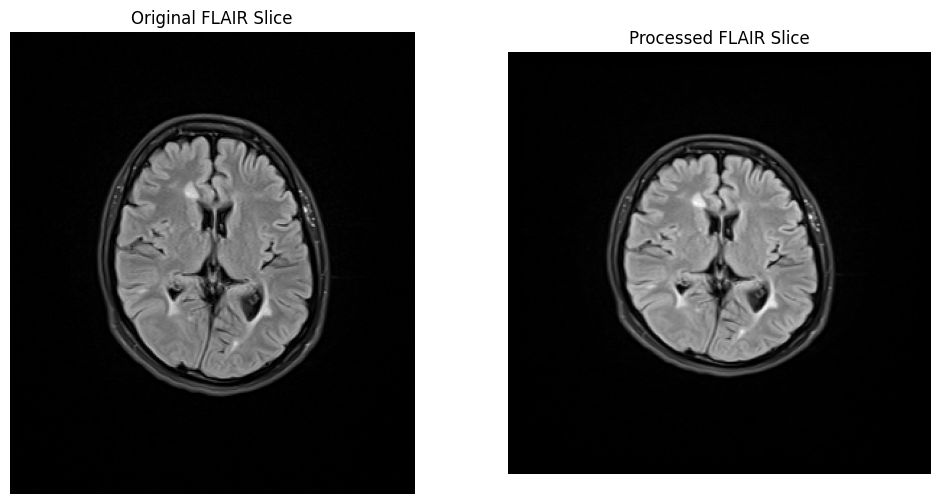

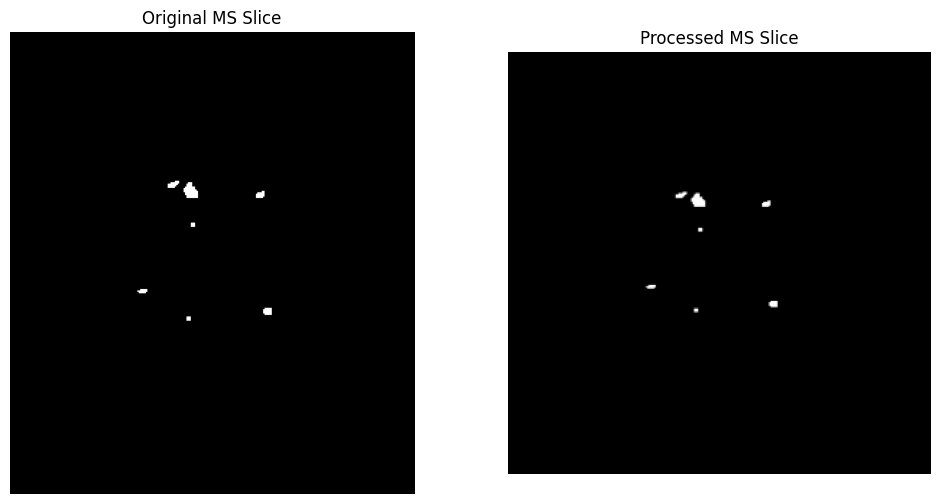

In [3]:
# Mount Google Drive
drive.mount('/content/drive')

# Data loading and preprocessing functions
def load_nii(path):
    nii = nib.load(path)
    return nii.get_fdata()

def pad_image_to_size(image, target_height=320, target_width=320, mode='constant'):
    """Pad the image to the target height and width."""
    current_height, current_width = image.shape[:2]
    delta_h = max(target_height - current_height, 0)
    delta_w = max(target_width - current_width, 0)
    top_pad = delta_h // 2
    bottom_pad = delta_h - top_pad
    left_pad = delta_w // 2
    right_pad = delta_w - left_pad
    padding = ((top_pad, bottom_pad), (left_pad, right_pad))
    padded_image = np.pad(image, padding, mode=mode)
    return padded_image

def preprocess_data(flair_slice, ms_slice, resize_target=(300, 300), pad_target=(320, 320)):
    """Normalize, resize, and pad a single slice of MRI data."""
    # Normalize the FLAIR slice
    flair_normalized = flair_slice / np.max(flair_slice) if np.max(flair_slice) > 0 else flair_slice

    # Binarize the MS slice
    ms_normalized = (ms_slice > 0.5).astype(np.float32)

    # Resize both slices to near target size
    flair_resized = resize(flair_normalized, resize_target, anti_aliasing=True)
    ms_resized = resize(ms_normalized, resize_target, anti_aliasing=True)

    # Pad both slices to ensure exact target dimensions
    flair_padded = pad_image_to_size(flair_resized, *pad_target)
    ms_padded = pad_image_to_size(ms_resized, *pad_target)

    return flair_padded, ms_padded


# Example of loading and preprocessing data
base_path = '/content/drive/My Drive/Semester 10/MS Dataset'
# Data loading and preprocessing code...
patient_number = 2
flair_image_path = f'{base_path}/Patient-{patient_number}/{patient_number}-Flair.nii'
flair_Seg_image_path = f'{base_path}/Patient-{patient_number}/{patient_number}-LesionSeg-Flair.nii'

# Load the FLAIR and MS data
flair_image = nib.load(flair_image_path)
flair_data = flair_image.get_fdata()
MS_image = nib.load(flair_Seg_image_path)
MS_data = MS_image.get_fdata()
volume_shape = flair_data.shape
print("Volume shape:", volume_shape)

# Size of an individual slice
slice_height = volume_shape[0]
slice_width = volume_shape[1]
print("Slice size (height, width):", (slice_height, slice_width))
# Specify the slice index you want to preprocess and visualize
slice_index = flair_data.shape[2] // 2  # or any specific index that is relevant

# Extract the specific slices
flair_slice = flair_data[:, :, slice_index]
MS_slice = MS_data[:, :, slice_index]

# Preprocess the extracted slices

flair_resized, MS_resized = preprocess_data(flair_slice, MS_slice)

# Visualize the original and processed slices
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(flair_slice, cmap='gray')
plt.title('Original FLAIR Slice')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(flair_resized, cmap='gray')
plt.title('Processed FLAIR Slice')
plt.axis('off')

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(MS_slice, cmap='gray')
plt.title('Original MS Slice')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(MS_resized, cmap='gray')
plt.title('Processed MS Slice')
plt.axis('off')

plt.show()


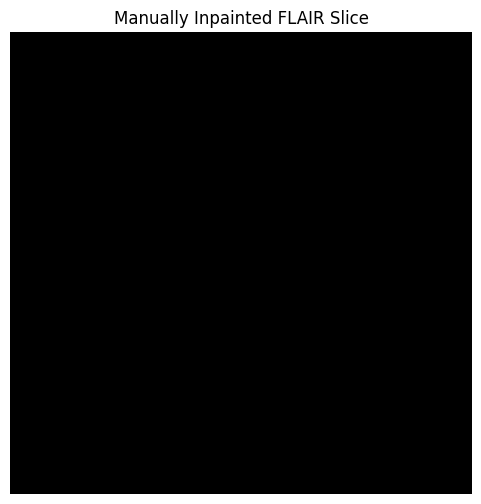

The image could not be loaded. Please check the file path.


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def manual_inpainting(flair_img, ms_mask, patch_size=(32, 32)):
    flair_img = cv2.normalize(flair_img, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

    # Invert the MS mask: lesions are 1, rest is 0
    ms_mask_inverted = 1 - ms_mask

    # Find contours of the lesions to define the regions to be inpainted
    contours, _ = cv2.findContours((ms_mask * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    inpainted_img = flair_img.copy()
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 0 and h > 0:
            patch_x = max(0, min(flair_img.shape[1] - w, x))
            patch_y = max(0, min(flair_img.shape[0] - h, y))
            patch = flair_img[patch_y:patch_y + h, patch_x:patch_x + w]

            # Place the patch directly over the lesion
            inpainted_img[y:y+h, x:x+w] = patch

            # Optionally apply a Gaussian blur to the edges for smoother blending
            if w > 2 and h > 2:  # Ensure the region is large enough for blurring
                inpainted_img[y:y+h, x:x+w] = cv2.GaussianBlur(inpainted_img[y:y+h, x:x+w], (3, 3), sigmaX=1, sigmaY=1)

    return inpainted_img

# Normalize and convert flair_resized to uint8 if necessary
flair_inpainted = manual_inpainting(flair_resized.astype(np.uint8), MS_resized)

# Display the inpainted image
plt.figure(figsize=(6, 6))
plt.imshow(flair_inpainted, cmap='gray')
plt.title('Manually Inpainted FLAIR Slice')
plt.axis('off')
plt.show()
import numpy as np
import matplotlib.pyplot as plt


# Check if the image is loaded correctly
if inpainted_img is None:
    print("The image could not be loaded. Please check the file path.")
else:
    # Check the intensity values range
    print(f"Image pixel value range: {inpainted_img.min()} to {inpainted_img.max()}")

    # If the range is too narrow, normalize the intensity for better visualization
    if inpainted_img.max() - inpainted_img.min() > 0:
        inpainted_img_normalized = cv2.normalize(inpainted_img, None, 0, 255, cv2.NORM_MINMAX)
    else:
        # If all values are the same, normalization won't help. Instead, we'll check if they are all zero.
        if np.all((inpainted_img == 0)):
            print("The image contains only zero values.")
        else:
            print("The image has non-zero values but lacks contrast.")
            # You could set all values to maximum to check the non-zero regions
            inpainted_img_normalized = np.where(inpainted_img > 0, 255, 0).astype('uint8')

    # Display the image after normalization
    plt.figure(figsize=(6, 6))
    plt.imshow(inpainted_img_normalized, cmap='gray')
    plt.title('Inpainted FLAIR Slice (Normalized for Visualization)')
    plt.axis('off')
    plt.show()



## Model Architecture
Below is the implementation of the U-Net model architecture used for our medical image segmentation task.


In [ ]:
### MODEL 1 ###
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout, Add, Flatten, Dense, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from IPython.display import clear_output
from tensorflow.keras.regularizers import l2  # Import L2 regularization

from tensorflow.keras.layers import Dropout  # Ensure Dropout is imported

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras import regularizers
# could add regularizer , kernel_regularizer=regularizers.l2(0.0005)
def build_alexnet(input_shape=(320, 320, 1)):
    inputs = Input(shape=input_shape)

    # Layer 1
    x = Conv2D(96, (11, 11), strides=4, padding='valid', kernel_regularizer=regularizers.l2(0.0005))(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    x = MaxPooling2D((3, 3), strides=2)(x)

    # Layer 2
    x = Conv2D(256, (5, 5), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    x = MaxPooling2D((3, 3), strides=2)(x)

    # Layer 3
    x = Conv2D(384, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Layer 4
    x = Conv2D(384, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Layer 5
    x = Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    x = MaxPooling2D((3, 3), strides=2)(x)

    # Flatten and Fully Connected Layers
    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)
    #x = Dropout(0.5)(x)
    #x = Dense(4096, activation='relu')(x)
    #x = Dropout(0.5)(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Usage
# model = build_alexnet()
 #model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#model.summary()







def iou(y_true, y_pred):
    """Calculate Intersection over Union for batches."""
    smooth = 1e-6
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3]) - intersection
    iou = tf.reduce_mean((intersection + smooth) / (union + smooth), axis=0)
    return iou




In [ ]:
### MODEL 2
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers

def build_vgg(input_shape=(320, 320, 1)):
    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(16, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    x = Conv2D(16, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    x = MaxPooling2D((2, 2))(x)

    # Block 2
    x = Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    x = Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    x = MaxPooling2D((2, 2))(x)

    # Block 3
    x = Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    #x = Dropout(0.25)(x)
    x = Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    #x = Dropout(0.25)(x)
    x = Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    #x = Dropout(0.25)(x)
    x = MaxPooling2D((2, 2))(x)

    # Block 4
    x = Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    x = Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    x = Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.0005))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    x = MaxPooling2D((2, 2))(x)

    # Flatten and Fully Connected Layers
    x = Flatten()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)

    # Output layer
    outputs = Dense(1, activation='sigmoid')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Create and compile the model
#model = build_vgg()

In [5]:
### MODEL 3
import torch
import torch.nn as nn
import torch.nn.functional as F

class DenseLayer(nn.Module):
    def __init__(self, input_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn1 = nn.BatchNorm2d(input_channels)
        self.conv1 = nn.Conv2d(input_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = torch.cat([x, out], 1)
        return out

class TransitionLayer(nn.Module):
    def __init__(self, input_channels, output_channels):
        super(TransitionLayer, self).__init__()
        self.bn1 = nn.BatchNorm2d(input_channels)
        self.conv1 = nn.Conv2d(input_channels, output_channels, kernel_size=1, bias=False)
        self.pool1 = nn.AvgPool2d(2)

    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.pool1(out)
        return out

class DenseBlock(nn.Module):
    def __init__(self, num_layers, input_channels, growth_rate):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(input_channels + i * growth_rate, growth_rate))
        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)

class DenseNet(nn.Module):
    def __init__(self, growth_rate=32, block_config=(6, 12, 24, 16), reduction=0.5, num_classes=1):
        super(DenseNet, self).__init__()
        num_channels = 2 * growth_rate
        self.conv1 = nn.Conv2d(1, num_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        blocks = []
        for num_layers in block_config:
            blocks.append(DenseBlock(num_layers, num_channels, growth_rate))
            num_channels += num_layers * growth_rate
            if num_layers != block_config[-1]:
                blocks.append(TransitionLayer(num_channels, int(num_channels * reduction)))
                num_channels = int(num_channels * reduction)
        self.features = nn.Sequential(*blocks)

        self.bn2 = nn.BatchNorm2d(num_channels)
        self.classifier = nn.Linear(num_channels, num_classes)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.features(x)
        x = F.relu(self.bn2(x))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
#model = DenseNet()
#print(model)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout, Add, Flatten, Dense, LeakyReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from IPython.display import clear_output
from tensorflow.keras.regularizers import l2  # Import L2 regularization

from tensorflow.keras.layers import Dropout  # Ensure Dropout is imported

def binary_classification_model(input_size=(320, 320, 1)):
    inputs = Input(input_size)
    # First block
    x1 = Conv2D(8, (3, 3), padding='same')(inputs)
    #x1 = BatchNormalization()(x1)
    x1 = LeakyReLU(alpha=0.01)(x1)
    x1 = Conv2D(8, (3, 3), padding='same')(x1)
    #x1 = BatchNormalization()(x1)
    x1 = LeakyReLU(alpha=0.01)(x1)
    x1_pooled = MaxPooling2D((2, 2))(x1)
    #x1_pooled = Dropout(0.5)(x1_pooled)

    # Second block with skip connection
    x2 = Conv2D(16, (3, 3), padding='same')(x1_pooled)
    #x2 = BatchNormalization()(x2)
    x2 = LeakyReLU(alpha=0.01)(x2)
    x2 = Conv2D(16, (3, 3), padding='same')(x2)
    #x2 = BatchNormalization()(x2)
    x2 = LeakyReLU(alpha=0.01)(x2)
    x2_pooled = MaxPooling2D((2, 2))(x2)
    #x2_pooled = Dropout(0.5)(x2_pooled)
    x2_adjusted = Conv2D(16, (1, 1), padding='same')(x1_pooled)
    x2_adjusted = MaxPooling2D((2, 2))(x2_adjusted)
    x2_final = Add()([x2_adjusted, x2_pooled])

    # Third block with skip connection
    x3 = Conv2D(32, (3, 3), padding='same')(x2_final)
    #x3 = BatchNormalization()(x3)
    x3 = LeakyReLU(alpha=0.01)(x3)
    x3 = Conv2D(32, (3, 3), padding='same')(x3)
    #x3 = BatchNormalization()(x3)
    x3 = LeakyReLU(alpha=0.01)(x3)
    x3_pooled = MaxPooling2D((2, 2))(x3)
    #x3_pooled = Dropout(0.5)(x3_pooled)
    x3_adjusted = Conv2D(32, (1, 1), padding='same')(x2_final)  # Adjust channel dimensions
    x3_adjusted = MaxPooling2D((2, 2))(x3_adjusted)  # Further adjust spatial dimensions
    x3_final = Add()([x3_adjusted, x3_pooled])

        # Fourth block with skip connection
    x4 = Conv2D(64, (3, 3), padding='same')(x3_final)
    #x4 = BatchNormalization()(x4)
    x4 = LeakyReLU(alpha=0.01)(x4)
    x4 = Conv2D(64, (3, 3), padding='same')(x4)
    #x4 = BatchNormalization()(x4)
    x4 = LeakyReLU(alpha=0.01)(x4)
    x4_pooled = MaxPooling2D((2, 2))(x4)

# Adjust x3_final to match x4 dimensions for skip connection
    x4_adjusted = Conv2D(64, (1, 1), padding='same')(x3_final)  # Adjust channels
    x4_adjusted = MaxPooling2D((2, 2))(x4_adjusted)  # Adjust spatial dimensions to match x4_pooled
    x4_final = Add()([x4_adjusted, x4_pooled])  # Add skip connection

    # Final dense layers
    x = Flatten()(x4_final)
    x = Dense(64)(x)
    #x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.01)(x)

    outputs = Dense(1, activation='sigmoid')(x)  # Binary output for classification
    model = Model(inputs=inputs, outputs=outputs)
    return model






def iou(y_true, y_pred):
    """Calculate Intersection over Union for batches."""
    smooth = 1e-6
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3]) - intersection
    iou = tf.reduce_mean((intersection + smooth) / (union + smooth), axis=0)
    return iou




In [ ]:
    # Fourth block with skip connection
    x4 = Conv2D(32, (3, 3), padding='same')(x3_final)
    x4 = BatchNormalization()(x4)
    x4 = LeakyReLU(alpha=0.01)(x4)
    x4 = Conv2D(32, (3, 3), padding='same')(x4)
    x4 = BatchNormalization()(x4)
    x4 = LeakyReLU(alpha=0.01)(x4)
    x4_pooled = MaxPooling2D((2, 2))(x4)

# Adjust x3_final to match x4 dimensions for skip connection
    x4_adjusted = Conv2D(32, (1, 1), padding='same')(x3_final)  # Adjust channels
    x4_adjusted = MaxPooling2D((2, 2))(x4_adjusted)  # Adjust spatial dimensions to match x4_pooled
    x4_final = Add()([x4_adjusted, x4_pooled])  # Add skip connection

NameError: name 'x3_final' is not defined

## Training the Model
We train the model using the full dataset. Monitoring loss and accuracy metrics helps to understand the model's performance.


In [6]:
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt
from IPython.display import clear_output

from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt
from IPython.display import clear_output

class PlotLosses(Callback):
    def on_train_begin(self, logs=None):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.acc = []
        self.val_acc = []

        self.fig = plt.figure()

        self.logs = []

    def on_epoch_end(self, epoch, logs=None):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.acc.append(logs.get('accuracy'))  # Ensure your model metrics include 'accuracy'
        self.val_acc.append(logs.get('val_accuracy'))
        self.i += 1

        clear_output(wait=True)
        plt.subplot(2, 1, 1)
        plt.plot(self.x, self.losses, label="Training loss")
        plt.plot(self.x, self.val_losses, label="Validation loss")
        plt.legend()
        plt.title('Training and Validation Loss')

        plt.subplot(2, 1, 2)
        plt.plot(self.x, self.acc, label="Training accuracy")
        plt.plot(self.x, self.val_acc, label="Validation accuracy")
        plt.legend()
        plt.title('Training and Validation Accuracy')

        plt.show()

plot_losses = PlotLosses()



In [7]:
from tensorflow.keras.callbacks import EarlyStopping
# Define the early stopping callback
early_stopper = EarlyStopping(
    monitor='val_loss',   # Metric to monitor
    min_delta=0.001,      # Minimum change to qualify as an improvement
    patience=15,          # Number of epochs with no improvement after which training will be stopped
    verbose=1,            # Output messages
    restore_best_weights=True  # Restores model weights from the epoch with the best value of the monitored quantity
)

In [8]:
#### FOR T2+ FLAIR
import random
def compile_data(base_path, num_patients):
    """Compile the image data and create binary labels for MS presence."""
    combined_images = []
    ms_labels = []

    for patient_number in range(1, num_patients + 1):
        flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-Flair.nii')
        t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-T2.nii')
        seg_flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-Flair.nii')
        seg_t2_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-T2.nii')

        flair_img = load_nii(flair_path)
        t2_img = load_nii(t2_path)
        ms_flair_img = load_nii(seg_flair_path)
        ms_t2_img = load_nii(seg_t2_path)

        for slice_idx in range(flair_img.shape[2]):
            flair_slice = flair_img[:, :, slice_idx]
            ms_slice = ms_flair_img[:, :, slice_idx]

            flair_processed = preprocess_data(flair_slice)
            combined_images.append(flair_processed)

            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)


        for slice_idx in range(t2_img.shape[2]):
            t2_slice = t2_img[:, :, slice_idx]
            ms_slice = ms_t2_img[:, :, slice_idx]
            t2_processed = preprocess_data(t2_slice)
            combined_images.append(t2_processed)
            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)

    X = np.array(combined_images)
    Y = np.array(ms_labels)

    return X, Y

num_patients = 60  # Total number of patients
X, Y = compile_data(base_path, num_patients)
import numpy as np
import os

base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset/T2_Flair_Data'

# Ensure the directory exists
os.makedirs(base_save_path, exist_ok=True)

# Save the arrays
np.save(os.path.join(base_save_path, 'X.npy'), X)
np.save(os.path.join(base_save_path, 'Y.npy'), Y)


KeyboardInterrupt: 

In [ ]:
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset'
# Save the arrays
np.save(os.path.join(base_save_path, 'X.npy'), X)
np.save(os.path.join(base_save_path, 'Y.npy'), Y)


In [ ]:
import random
def compile_data(base_path, num_patients):
    """Compile the image data and create binary labels for MS presence."""
    flair_images = []
    ms_labels = []  # Changed from ms_masks to ms_labels

    for patient_number in range(1, num_patients + 1):
        flair_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-Flair.nii')
        seg_path = os.path.join(base_path, f'Patient-{patient_number}', f'{patient_number}-LesionSeg-Flair.nii')

        flair_img = load_nii(flair_path)
        ms_img = load_nii(seg_path)

        for slice_idx in range(flair_img.shape[2]):
            flair_slice = flair_img[:, :, slice_idx]
            ms_slice = ms_img[:, :, slice_idx]

            flair_processed, _ = preprocess_data(flair_slice, ms_slice)
            flair_images.append(flair_processed)

            # Create a binary label based on the presence of lesions
            ms_label = 1 if np.max(ms_slice) > 0 else 0
            ms_labels.append(ms_label)

    X = np.array(flair_images)
    X = np.expand_dims(X, axis=-1)
    Y = np.array(ms_labels)

    return X, Y

num_patients = 60  # Total number of patients
X, Y = compile_data(base_path, num_patients)



In [9]:
# Load the saved data
base_save_path = '/content/drive/My Drive/Semester 10/MS Dataset'
X = np.load(os.path.join(base_save_path, 'X.npy'))
Y = np.load(os.path.join(base_save_path, 'Y.npy'))

print("Data loaded successfully:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)


Data loaded successfully:
X shape: (2831, 320, 320)
Y shape: (2831,)


In [10]:
import numpy as np

# Assuming Y is your array of labels
labels, counts = np.unique(Y, return_counts=True)
print("Label distribution:", dict(zip(labels, counts)))


Label distribution: {0: 1401, 1: 1430}


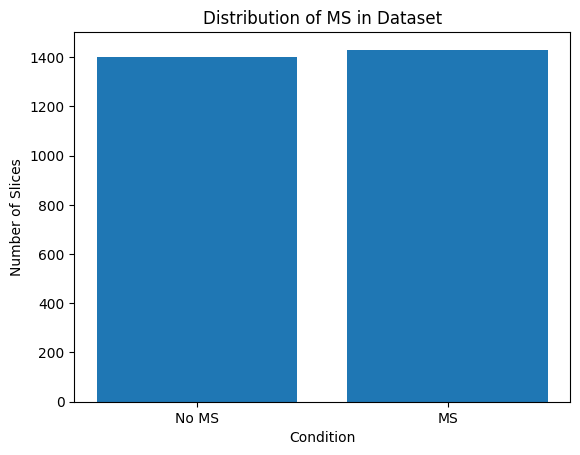

In [11]:
import matplotlib.pyplot as plt

plt.bar(labels, counts, tick_label=['No MS', 'MS'])
plt.xlabel('Condition')
plt.ylabel('Number of Slices')
plt.title('Distribution of MS in Dataset')
plt.show()


In [12]:
from sklearn.model_selection import train_test_split
X = np.expand_dims(X, axis=-1)
# Split the data into training+validation (80%) and testing (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

# Split the training and validation set (from the 80% "train_val" split, allocate 20% to validation)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20, # You can comment this out if you want to test the impact of removing rotations
    horizontal_flip=True, # You can comment this out if you want to test the impact of removing horizontal flips
    vertical_flip=True, # You can comment this out if you want to test the impact of removing vertical flips
    width_shift_range=0.2,  # randomly shift images horizontally (10% of total width)
    height_shift_range=0.2,  # randomly shift images vertically (10% of total height)
    fill_mode='nearest'  # Fill in any empty pixels after the shift with the nearest pixel values
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)

In [26]:
class FiniteDataGeneratorWrapper:
    def __init__(self, generator, num_steps):
        self.generator = generator
        self.num_steps = num_steps
        self.step = 0

    def __iter__(self):
        return self

    def __next__(self):
        if self.step < self.num_steps:
            self.step += 1
            return next(self.generator)
        else:
            self.step = 0
            raise StopIteration

num_train_steps = len(X_train) // 32
num_val_steps = len(X_val) // 32

train_generator = FiniteDataGeneratorWrapper(train_datagen.flow(X_train, y_train, batch_size=32), num_train_steps)
val_generator = FiniteDataGeneratorWrapper(val_datagen.flow(X_val, y_val, batch_size=32), num_val_steps)


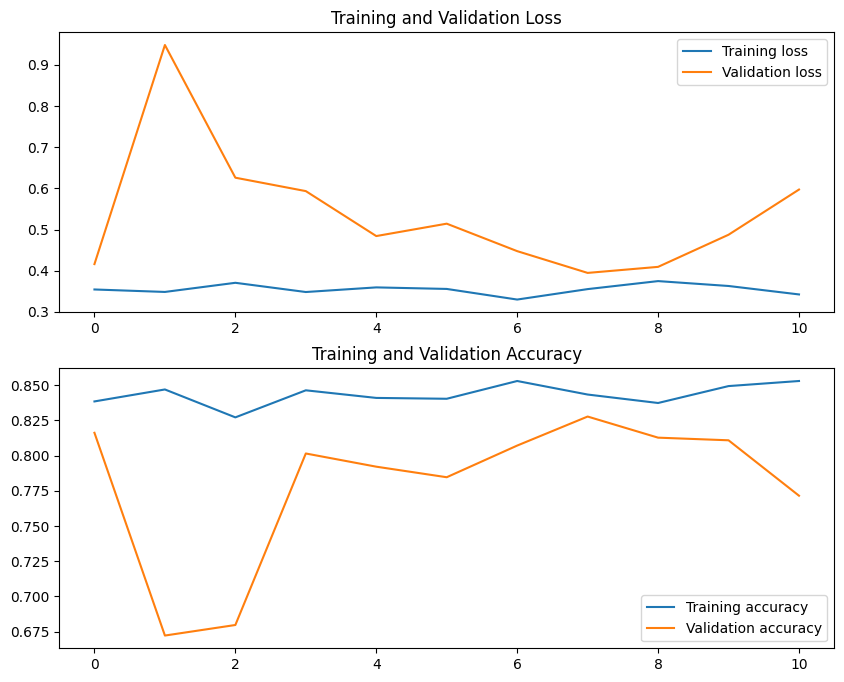

Epoch [12/250]: : 31it [00:29,  1.05it/s, accuracy=0.854, loss=0.331]

In [ ]:
import torch
from torch.optim import Adam
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm import tqdm

class TrainMonitor:
    def __init__(self):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.acc = []
        self.val_acc = []

    def update(self, train_loss, val_loss, train_acc, val_acc):
        self.x.append(self.i)
        self.losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.acc.append(train_acc)
        self.val_acc.append(val_acc)
        self.i += 1

        clear_output(wait=True)
        plt.figure(figsize=(10, 8))

        plt.subplot(2, 1, 1)
        plt.plot(self.x, self.losses, label="Training loss")
        plt.plot(self.x, self.val_losses, label="Validation loss")
        plt.title('Training and Validation Loss')
        plt.legend()

        plt.subplot(2, 1, 2)
        plt.plot(self.x, self.acc, label="Training accuracy")
        plt.plot(self.x, self.val_acc, label="Validation accuracy")
        plt.title('Training and Validation Accuracy')
        plt.legend()

        plt.pause(0.1)  # Allows the plot to update in real-time
        plt.show()

def train_model(model, train_loader, val_loader, num_epochs=250, monitor=None):
    model.to(device)
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        total_train = 0

        loop = tqdm(train_loader, leave=True)  # Progress bar for the training loop
        for data, targets in loop:
            data = torch.tensor(data, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
            targets = torch.tensor(targets, dtype=torch.float32).to(device)

            optimizer.zero_grad()
            outputs = model(data)
            outputs = outputs.squeeze()
            loss = F.binary_cross_entropy_with_logits(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * data.size(0)
            preds = outputs.sigmoid().round()
            train_correct += (preds == targets).sum().item()
            total_train += data.size(0)

            # Update progress bar description
            loop.set_description(f'Epoch [{epoch+1}/{num_epochs}]')
            loop.set_postfix(loss=train_loss / total_train, accuracy=train_correct / total_train)

        train_loss /= total_train
        train_acc = train_correct / total_train

        # Validation phase
        val_loss = 0
        val_correct = 0
        total_val = 0
        model.eval()
        with torch.no_grad():
            for data, targets in val_loader:
                data = torch.tensor(data, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
                targets = torch.tensor(targets, dtype=torch.float32).to(device)
                outputs = model(data)
                outputs = outputs.squeeze()
                loss = F.binary_cross_entropy_with_logits(outputs, targets)

                val_loss += loss.item() * data.size(0)
                preds = outputs.sigmoid().round()
                val_correct += (preds == targets).sum().item()
                total_val += data.size(0)

        val_loss /= total_val
        val_acc = val_correct / total_val

        if monitor:
            monitor.update(train_loss, val_loss, train_acc, val_acc)

# Set up the monitor and train the model
monitor = TrainMonitor()
train_model(model, train_generator, val_generator, num_epochs=250, monitor=monitor)


In [14]:
plot_losses = PlotLosses()
#model = build_vgg()
model = DenseNet()
#model = build_alexnet()
# model = binary_classification_model()
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model using the data generators
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=250,
    callbacks=[early_stopper,plot_losses],
    verbose=1
)



TypeError: compile() got an unexpected keyword argument 'optimizer'

## Evaluation and Testing
Evaluate the model on a separate test set and display the results to assess the model's generalization capability.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict classes
pred_classes = model.predict(X_test) > 0.5

# Evaluate the model
print(classification_report(y_test, pred_classes))
conf_matrix = confusion_matrix(y_test, pred_classes)
print(conf_matrix)



10/10 [==============================] - 1s 38ms/step
              precision    recall  f1-score   support

           0       0.91      0.84      0.87       143
           1       0.86      0.92      0.89       148

    accuracy                           0.88       291
   macro avg       0.88      0.88      0.88       291
weighted avg       0.88      0.88      0.88       291

[[120  23]
 [ 12 136]]


## Results Visualization
Display original images, their true masks, and the masks predicted by our model to visually assess the performance.


In [ ]:
def visualize_predictions(X, y, preds, num_samples=20):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, num_samples * 5))
    for i in range(num_samples):
        axes[i, 0].imshow(X[i, :, :, 0], cmap='gray')
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(X[i, :, :, 0], cmap='gray')  # Re-displaying the same image for layout consistency
        axes[i, 1].set_title('True Label: {}'.format('MS' if y[i] else 'No MS'))
        axes[i, 1].axis('off')

        axes[i, 2].imshow(X[i, :, :, 0], cmap='gray')  # Re-displaying the same image for layout consistency
        axes[i, 2].set_title('Predicted: {:.2f}% MS'.format(preds[i][0] * 100))
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.show()

# Predict probabilities
pred_probs = model.predict(X_test)
visualize_predictions(X_test, y_test, pred_probs)

